In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.optimizers import Adam

In [36]:
base_dir = "/Users/vihangainduwara/Desktop/MelanoDetect/data/ham10000"

metadata_path = os.path.join(base_dir, "HAM10000_metadata.csv")
image_dir_1 = os.path.join(base_dir, "HAM10000_images_part_1")
image_dir_2 = os.path.join(base_dir, "HAM10000_images_part_2")

print("Metadata exists:", os.path.exists(metadata_path))
print("Image dir 1 exists:", os.path.exists(image_dir_1))
print("Image dir 2 exists:", os.path.exists(image_dir_2))

Metadata exists: True
Image dir 1 exists: True
Image dir 2 exists: True


In [37]:
df = pd.read_csv(metadata_path)
print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [38]:
def get_image_path(image_id):
    file_name = image_id + ".jpg"

    path1 = os.path.join(image_dir_1, file_name)
    path2 = os.path.join(image_dir_2, file_name)

    if os.path.exists(path1):
        return path1
    elif os.path.exists(path2):
        return path2
    else:
        return None

df["image_path"] = df["image_id"].apply(get_image_path)
df = df.dropna(subset=["image_path"]).copy()

print("Remaining rows:", len(df))

Remaining rows: 10015


In [39]:
binary_map = {
    "mel": "malignant",
    "bcc": "malignant",
    "akiec": "malignant",
    "nv": "benign",
    "bkl": "benign",
    "df": "benign",
    "vasc": "benign"
}

df["binary_label"] = df["dx"].map(binary_map)
df["label_num"] = df["binary_label"].map({"benign": 0, "malignant": 1})

print(df["binary_label"].value_counts())

binary_label
benign       8061
malignant    1954
Name: count, dtype: int64


In [40]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label_num"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_num"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 7010
Validation size: 1502
Test size: 1503


In [41]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_num"]),
    y=train_df["label_num"]
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

Class weights: {0: np.float64(0.6212336051045728), 1: np.float64(2.5621345029239766)}


In [42]:
IMG_SIZE = 240
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

In [43]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 7010 validated image filenames belonging to 2 classes.
Found 1502 validated image filenames belonging to 2 classes.
Found 1503 validated image filenames belonging to 2 classes.


In [44]:
base_model = EfficientNetB1(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 240, 240,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 240, 240,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 240, 240,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 241, 241,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 120, 120,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 120, 120,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 120, 120,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 120, 120,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 120, 120,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 120, 120,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 120, 120,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 120, 120,  │        512 │ block1a_se_excit

 Total params: 6,908,552 (26.35 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 6,577,799 (25.09 MB)

In [45]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        "efficientnet_b1_stage1_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
history_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
158/220 ━━━━━━━━━━━━━━━━━━━━ 33s 541ms/step - accuracy: 0.6728 - loss: 0.7742

In [13]:
from tensorflow.keras.models import load_model

model = load_model("efficientnet_b1_stage1_best.keras")
print("B1 best model loaded")

B1 best model loaded


In [14]:
y_probs = model.predict(test_generator).flatten()
y_true = test_df["label_num"].values

print("Predictions:", len(y_probs))
print("Sample probs:", y_probs[:10])

47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 480ms/step
Predictions: 1503
Sample probs: [4.6555471e-01 7.9492432e-01 9.4213194e-01 7.0752281e-01 1.7064040e-04
 9.9345982e-02 7.4855285e-05 7.0659131e-05 1.8144356e-01 2.2088882e-01]


Accuracy: 0.7977378576180971
              precision    recall  f1-score   support

      Benign       0.95      0.79      0.86      1210
   Malignant       0.49      0.83      0.61       293

    accuracy                           0.80      1503
   macro avg       0.72      0.81      0.74      1503
weighted avg       0.86      0.80      0.81      1503



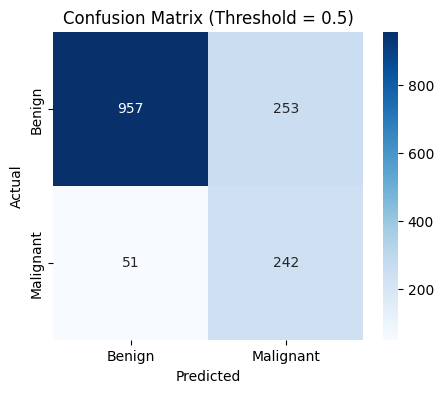

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = (y_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"])
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


===== Threshold = 0.5 =====
Accuracy: 0.7977
              precision    recall  f1-score   support

      Benign       0.95      0.79      0.86      1210
   Malignant       0.49      0.83      0.61       293

    accuracy                           0.80      1503
   macro avg       0.72      0.81      0.74      1503
weighted avg       0.86      0.80      0.81      1503



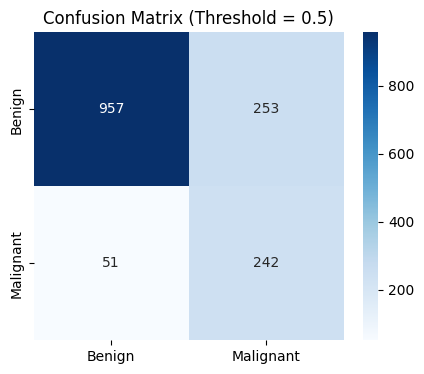


===== Threshold = 0.45 =====
Accuracy: 0.7784
              precision    recall  f1-score   support

      Benign       0.96      0.76      0.85      1210
   Malignant       0.46      0.86      0.60       293

    accuracy                           0.78      1503
   macro avg       0.71      0.81      0.72      1503
weighted avg       0.86      0.78      0.80      1503



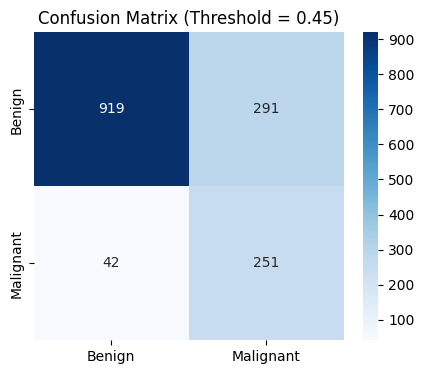


===== Threshold = 0.4 =====
Accuracy: 0.7578
              precision    recall  f1-score   support

      Benign       0.96      0.73      0.83      1210
   Malignant       0.44      0.88      0.59       293

    accuracy                           0.76      1503
   macro avg       0.70      0.80      0.71      1503
weighted avg       0.86      0.76      0.78      1503



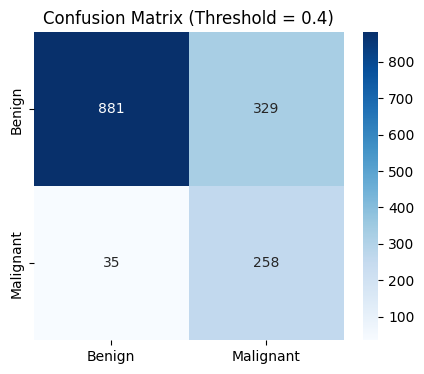


===== Threshold = 0.35 =====
Accuracy: 0.7312
              precision    recall  f1-score   support

      Benign       0.97      0.69      0.81      1210
   Malignant       0.41      0.90      0.57       293

    accuracy                           0.73      1503
   macro avg       0.69      0.80      0.69      1503
weighted avg       0.86      0.73      0.76      1503



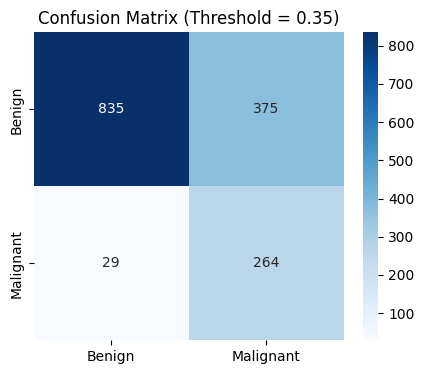


===== Threshold = 0.3 =====
Accuracy: 0.7119
              precision    recall  f1-score   support

      Benign       0.97      0.66      0.79      1210
   Malignant       0.40      0.92      0.56       293

    accuracy                           0.71      1503
   macro avg       0.69      0.79      0.67      1503
weighted avg       0.86      0.71      0.74      1503



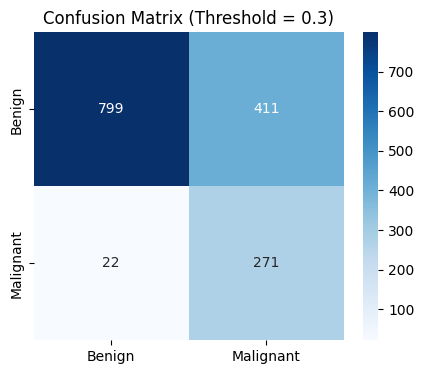

In [16]:
thresholds = [0.5, 0.45, 0.4, 0.35, 0.3]

for threshold in thresholds:
    y_pred = (y_probs > threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== Threshold = {threshold} =====")
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, y_pred,
          target_names=["Benign", "Malignant"], zero_division=0))

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Confusion Matrix (Threshold = {threshold})")
    plt.show()

In [24]:
IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="binary_num",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",   # important because binary_num is 0/1 numeric
    shuffle=False
)

KeyError: 'binary_num'

In [25]:
print(df.columns)
print(test_df.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'binary_label', 'label_num'],
      dtype='object')
Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'binary_label', 'label_num'],
      dtype='object')


from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (260, 260)
BATCH_SIZE = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label_num",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

In [26]:
y_prob = model.predict(test_generator, verbose=1).flatten()
y_pred = (y_prob > 0.5).astype(int)
y_true = test_df["label_num"].values

47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 571ms/step


Confusion Matrix:
[[816 394]
 [224  69]]


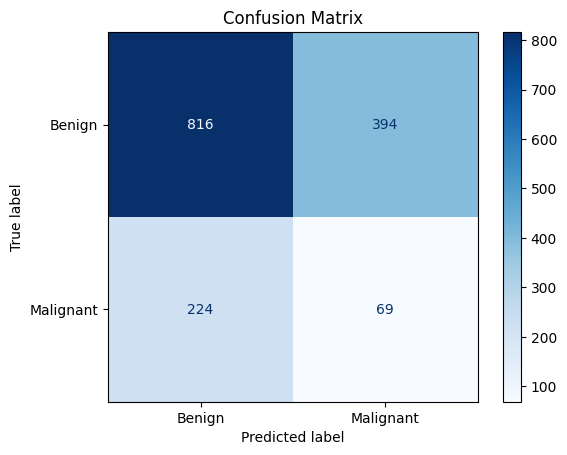

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [28]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))

Classification Report:
              precision    recall  f1-score   support

      Benign       0.78      0.67      0.73      1210
   Malignant       0.15      0.24      0.18       293

    accuracy                           0.59      1503
   macro avg       0.47      0.45      0.45      1503
weighted avg       0.66      0.59      0.62      1503



In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.5888
Precision : 0.1490
Recall    : 0.2355
F1-Score  : 0.1825


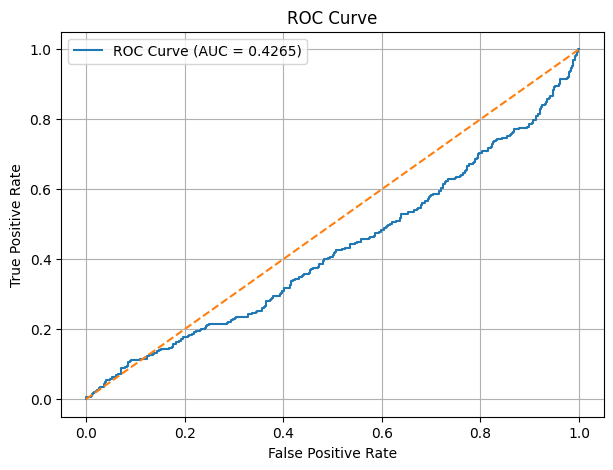

AUC Score : 0.4265


In [30]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Score : {roc_auc:.4f}")

In [31]:
print(history.history.keys())

NameError: name 'history' is not defined

In [32]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 700x500 with 0 Axes>

In [33]:
import os
print(os.listdir("."))
print(os.listdir(".."))

['04_input_validator.ipynb', '.DS_Store', '06_efficientnet_b1_binary.ipynb', '02_dataset_exploration.ipynb', '.ipynb_checkpoints', '05_efficientnet_binary_improved.ipynb', '03_efficientnet_binary..ipynb', '01_initial_dataset_work.ipynb']
['.venv-1', '.DS_Store', 'app', 'requirements.txt', 'models', 'docs', 'README.md', 'results', '.gitignore', '.venv', '.git', 'data', 'notebooks']
